In [5]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [6]:
# Load and preprocess data
data = pd.read_csv('AirtrafficA4.csv')
data['PASSENGERS CARRIED'] = data['PASSENGERS CARRIED'].str.replace(',', '').astype(float)
invalid_month_rows = data[~data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]
data = data[data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]

# Create 'DATE' column
data['DATE'] = pd.to_datetime(data['YEAR'].astype(str) + '-' + data['MONTH'], format='%Y-%b')
data = data.sort_values('DATE').set_index('DATE')

# Prepare the data in Prophet-compatible format
df = data[['PASSENGERS CARRIED']].reset_index().rename(columns={'DATE': 'ds', 'PASSENGERS CARRIED': 'y'})


17:44:22 - cmdstanpy - INFO - Chain [1] start processing
17:44:22 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\aksgu\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


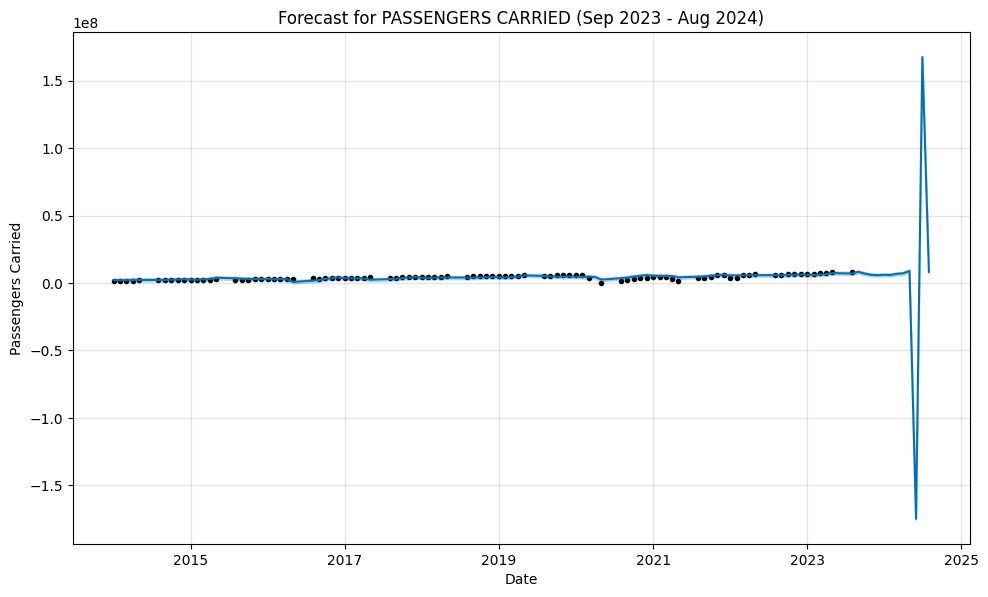

In [7]:
# Initialize and fit the Prophet model
model = Prophet()
model.fit(df)

# Create a future dataframe for 12 months ahead (Sep 2023 to Aug 2024)
future = model.make_future_dataframe(periods=12, freq='M')

# Generate forecast
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)
plt.title("Forecast for PASSENGERS CARRIED (Sep 2023 - Aug 2024)")
plt.xlabel("Date")
plt.ylabel("Passengers Carried")
plt.show()

# Display forecasted values for the prediction period
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

# Save the forecasted data for submission format
forecast_df = forecast[['ds', 'yhat']].tail(12).copy()
forecast_df.columns = ['YEAR_MONTH', 'PASSENGERS CARRIED']
forecast_df['YEAR_MONTH'] = forecast_df['YEAR_MONTH'].dt.strftime('%Y %b').str.upper()
forecast_df.to_csv('submission.csv', index=False)
